# 18 The MG90's two-node thermal model

Copper's handbook slope says how a winding's resistance moves with its temperature (notebook 17).
It does not say how hot the winding gets when the servo works. For that the firmware needs a
thermal model, how much the
winding rises per watt, how fast, and how much of that rise the can shares, so that it can predict
the winding from the power it is putting in and stop before the enamel does.

So I heated the MG90 on the bench, in room air on its mount, with the K thermocouple bead back on the
can. Two heater blocks, one at a quarter watt with an open-loop dither and one at 0.42 W with
closed-loop position steps, each followed by a cool-down with a burst every 30 s. Then a locked-rotor
hold against the low stop for ten minutes, where the firmware's own identification aggregates read
R while the current flowed. The thermocouple is the can truth, the burst thermometer is the winding
sensor, and the model in between is a two-node one. The
questions were:

1. What does one watt do to the can, and how fast, with the servo in free air?
2. What does the winding sit at over the can while the heat flows, and how fast does it get there?
3. Do the two blocks and the hold agree on one set of thermal constants, and which of those
   constants does this data actually pin?
4. What does the model predict for a stall, and where does it stop being valid?

If you are short on time, here is the whole answer up front:

- **The can to air is 32 C/W and takes about two minutes.** At 0.246 W the can settled 7.3 C over
  room, at 0.418 W 13.0 C, the same 30 to 31 C/W by the heater's own power and 35 to 37 by the power
  averaged over the burst breaks. The two-node fit with the real on-off profile lands between them,
  32.0 C/W, and both blocks fit it to 0.25 C. The slow mode is 129 s. The single-exponential time
  constants that come straight off the curves, 123 and 221 s heating, 168 and 130 s cooling, differ
  for reasons that are mostly not the servo. The 0.42 W block's power rose 18% through the block,
  which stretches its heating curve, and the 0.25 W block's cool-down was logged from 160 s after
  the heater stopped, which skips the fast part. The model fed the real power profiles gives the
  0.42 W block's two back, 205 and 129 s, and runs slow on the quarter-watt block, 172 s against 123,
  which is the one place two nodes do not quite cover this data.
- **The winding sits about 10 C over the can at a quarter watt, and the data brackets winding to
  can at 28 to 45 C/W.** The bursts inside the 0.25 W block read the winding at 44 C against a can at
  34, 10 C over, each burst scattering 2% of R, 5 C. The can's own response says 28 +/- 3 C/W and a
  winding heat capacity of 1.3 J/C, a few grams of copper and iron. The bursts want 40 to 45. The locked hold, read through the firmware's aggregates, says 27 to 32 at its peak. The winding over
  the air is then 60 to 77 C/W, and the fast mode about 20 s. The free bursts are the weakest of the three routes, since each is a ratio across brush seats, which carries contact steps as temperature
  (section 3).
- **The 0.42 W block's bursts are not a thermometer.** They read 4 to 16% over copper from the can,
  and the excess climbs through the cool-down with the can flat at 27 C. The bench RCA the same night
  put it in the circuit, not the winding. Those bursts are shown and kept out of every fit.
- **What the data cannot say.** The 1 W point was never taken, because the position-step heater caps
  near 0.42 W whatever the current limit (the trajectory's acceleration limit sets the current, and
  it is stamp covered). Without it the model's linearity above 13 C of can rise is assumed. The
  winding parameters lean on a 2% thermometer read 11 times, and on a hold taken in the excess state.
- **The prediction.** At the 280-count current limit (0.253 A) a stalled winding settles near 50 C
  with the can at 37, 20 to 24 C over the room, which is safe forever. A hard stall on the 2S rail
  with the limiter off puts 11.6 W into the winding and the model crosses 130 C in 12 to 17 s, with
  the can only 7 to 14 C up by then. A can sensor would be late by most of that race, so the winding
  thermometer is the sensor that sees it in time.

## Picking a rig

One dataset, `mg90-a__dev-v006-2A__2s__heating`. Like notebook 17's, its burst captures carry no
`sense` block, so the board cannot be read off the data. The bench log says rev 2A board #1, so I
name it here, and the table below is what that choice means. The supply is the 2S pack, which sagged
from 7.88 to 7.43 V over the night.

In [1]:
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import least_squares
from IPython.display import display

import oscnb
from oscnb import boards, datasets, servos, heating as hc, thermal as th

DS = datasets.load("mg90-a__dev-v006-2A__2s__heating")
# The burst captures carry no sense block, so the board cannot be read off the data. The bench
# log names it: rev 2A board #1, the same as notebook 17.
board, servo = boards.BOARDS["dev-v006-2A"], servos.SERVOS["mg90-a"]
rig = oscnb.Rig(board, servo).show()

K_CU = th.T0_CU                                # copper: R is proportional to (234.5 + T in C), oscnb.thermal
PDT = dt.timezone(dt.timedelta(hours=-7))      # the bench clock, US Pacific daylight time
BLK = hc.blocks(DS).set_index("capture")       # the index: one row per capture folder


def clock(u):
    return dt.datetime.fromtimestamp(float(u), PDT)


# Every capture's thermocouple log, heater polls and burst runs, loaded once.
CAN = {c: hc.can_log(DS, c) for c in BLK.index if (DS.path / c / "temp.csv").exists()}   # the hold logs its can in hold.csv
HEAT = {c: hc.heater(DS, c) for c in BLK.index if (DS.path / c / "heater.csv.gz").exists()}
BURSTS = {c: hc.bursts(DS, c) for c in BLK.index}
HOLD = hc.hold(DS, "hold/capture-1", board)
print("thermocouple glitches set aside: " + ", ".join(f"{c} {int(t.glitch.sum())}" for c, t in CAN.items()))

Vorpal MG90 clone, unit A on osc-dev-v006 rev 2A, board #1

  board: Rs1 60 mOhm; bare OPA with Rf 6k4 / Rg 430 (G 14.884), Cc 22 pF, Co1 DNP. Terminal taps Rv1/Rv3 6k4 over Rv2/Rv4 1k6 with Cv1/Cv2 100 pF, bottoms and caps returned to VB from Rb1 430 / Rb2 100 (773 counts nominal, about 81 ohm source, so VB rises with the leg current under drive). VSNS 6k4/1k6 to GND, unbiased, Cv3 100 pF. A 2A capture's sense block differs from board D's in gain_milli and both divider legs. Nothing in the block carries the bias or VSNS parts, or which 2A unit took the capture, so every 2A board shares this entry. Board #1 had Rv3 open for the grid-3r7 2S session: in that dataset tap B reads the VB node instead of terminal B, so only tap A, the rail and the current are graded there. Rv3 is repaired, and a dataset captured with it fitted reads both taps. Floors 64/93 ticks: the current at 3% with the settle gain on top (nb10 sec 8), the terminals from the grid ladder with tap B sampled 37 ticks before 

value
where            quantity                                           unit                          
board            converter step                                     mV per count            0.8057
                 terminal divider ratio r                                                   5.0000
                 terminal difference                                mV per count            4.0283
                 terminal bias VB                                   mV                    622.6415
                                                                    counts                772.8302
                 driven-low terminal reads                          counts                618.2642
                 motor current                                      mA per count            0.9022
                                                                    counts per A         1108.4521
                 shunt                                              mOhm                   60.0000
                 amplifier gain                                     x                      14.8840
                 rail tap ratio                                                             5.0000
                 sample rate                                        samples per ms         20.0000
                 current settled from                               % duty                  5.3333
                 voltage settled from                               % duty                  7.7500
servo            pot intercept                                      counts                209.0000
                 pot slope                                          counts per degree      19.7600
                 envelope low                                       counts (15.74 deg)    520.0224
                 envelope high                                      counts (168.59 deg)  3540.3384
                 runway                                             counts               3020.3160
                 seek guard low                                     counts                520.0000
                 seek guard high                                    counts               3540.0000
servo (measured) gear_ratio_measured [308.053, 308.053] mechanic... :1                    308.0533
                 ripple_order_measured [6, 6] teardown, 3-slot b... per motor rev           6.0000
                 r_winding_measured [4.49, 4.98] bringup capture... Ohm                     4.8900
                 ke_ripple_measured [1.284, 1.306] nb09 sec 3, s... mV per ripple Hz        1.2950
                 pot_scale_measured [19.7, 19.85] nb09 sec 10, r... counts/deg             19.7600
                 travel_measured [178.67, 189.18] nb09 sec 10, p... deg                   184.2200
                 low_stop_after_stall_measured [232, 236] hand s... counts                232.0000
                 backlash_measured [1.25, 1.5] nb09 sec 4, rever... ripple cycles           1.4800

thermocouple glitches set aside: rest/capture-1 0, dither/capture-1 0, dither/capture-2 0, steps/capture-1 0, steps/trial-1 0, steps/trial-2 0, steps/trial-3 0


## 1. The experiment

- **Procedure.** The MG90 sits on its bench mount in room air, horn state as the bench left it (not
  recorded), with the board beside it on the 2S pack. The thermocouple bead is taped to the motor
  can and read every 5 s. A block starts with the servo rested, takes or reuses a reference R at
  rest, then runs a heater at mid travel for 120 s, stops it for an `osc ident burst` run of about
  20 s, re-centres, and repeats, until the can is flat or the clock runs out. A cool-down follows
  with torque off and a burst every 30 s. The hold seats the shaft against the low stop and holds
  -20% duty under the stall permit for 10 minutes, reading the firmware's identification aggregates
  every 0.2 s, then cools with a burst every 60 s.
- **Model.** Two nodes. Heat $P = I^2 R(T_w)$ enters the winding at $T_w$, crosses $R_{wc}$ to the
  can at $T_c$, and leaves the can through $R_{ca}$ to the air at $T_a$:

$$C_w \frac{dT_w}{dt} = I^2 R(T_w) - \frac{T_w - T_c}{R_{wc}}, \qquad
C_c \frac{dT_c}{dt} = \frac{T_w - T_c}{R_{wc}} - \frac{T_c - T_a}{R_{ca}}$$

  with $R(T_w)$ on copper's line through the block's $R_{ref}$, so the heat grows as the winding
  warms. $R_{th}$ is a **thermal resistance** in C per watt, how many degrees over its neighbour one
  watt holds a node at once it settles. $C$ is a **heat capacity** in joules per C. The product
  $\tau = R C$ is a time constant in seconds. With the current held over a segment the system is
  linear, so `oscnb.thermal.TwoNode` steps it exactly from one event to the next.
- **Estimators.** The can is the thermocouple. The winding is copper's handbook line (notebook 17 sec 4) through the block's $R_{ref}$, on the waveform-fit R of each burst run, $T = T_{ref} + (R / R_{ref} - 1)(234.5 + T_{ref})$. The heater's
  power is its own current poll, $i_{hat}^2$ averaged over 5 s bins and multiplied by $R(T_w)$ inside
  the model. Inside the hold the winding is the firmware's aggregate R, read as a ratio to its own
  start. The time constants come two ways, one exponential straight through each curve, and the
  two-node fit through everything at once.
- **Validity envelope.** One MG90 in free air on this mount, can 26 to 41 C, room 26.5 to 27.3 C,
  0.25 to 0.42 W of winding heat with the shaft moving, 0.27 W locked. The rail fell from 7.88 to
  7.43 V over the night.
- **Accuracy.** The can is graded against nothing but itself (one thermocouple, one placement).
  The winding is graded against the can at rest, where the two must agree, and against the hold's
  aggregate, a second route into R.

Two heaters ran, because the first one was not safe. The **dither** is an open-loop square wave at
mid travel, the sign flipped when the shaft passes 100 counts either side of centre, amplitude from
20% stepping to a 30% cap, with the 280-count limiter left in. The limiter governed. The applied duty
averaged 19.5% against the 30% command, so the current, 0.228 A rms, was the limiter's and the power
was a quarter watt whatever the amplitude. The first attempt at it (rest/capture-1) stopped 26 s in
when a 75 ms host stall made a reversal late and the shaft ran 450 counts past the turn point into
the position guard. The second ran 29 minutes and then left anyway, to pos 3351 against a guard of
1000 counts. The **position steps** are the kernel's own Position mode with the goal toggled between
2045 - 300 and 2045 + 300 every 80 ms. It held its band and never faulted, but its current is set by
the trajectory's acceleration limit, not by the current limit. With the limit raised to 520 counts
in RAM it drew 0.299 A rms, 0.42 W, and the three one-minute trials before it (steps/trial-N) show
the same cap. Raising the acceleration limit in RAM latches STAMP_MISMATCH, since that field is
covered by the identified-set stamp, and the closed loop refuses to run. So the 1 W point was not
taken.

In [2]:
rows = []
for c, b in BLK.iterrows():
    t, bu = CAN.get(c, HOLD if c.startswith("hold") else None), BURSTS[c]
    first = min(t.unix.min(), bu.unix.min())
    last = max(t.unix.max(), bu.unix.max())
    r = {"capture": c, "from": clock(first).strftime("%H:%M"), "to": clock(last).strftime("%H:%M"),
         "what": b.label, "heater": b.heater, "limit": b.limit_counts, "runs": len(bu),
         "can C": f"{t.can_c.min():.1f}..{t.can_c.max():.1f}" if t.can_c.notna().any() else ""}
    if c in HEAT and len(HEAT[c]):
        h = HEAT[c]
        win, on_s = hc.heat_windows(h, board)
        wall = h.unix.iloc[-1] - h.unix.iloc[0]
        i2 = np.mean([q for _, _, q in win])                      # the heater's mean I^2 while it ran
        r.update({"heater min": wall / 60, "on %": on_s / wall * 100, "i rms A": np.sqrt(i2),
                  "P on W": i2 * b.r_ref_ohm, "P wall W": i2 * b.r_ref_ohm * on_s / wall,
                  "|duty| %": h.duty_applied.abs().mean() / 327.67})
    rows.append(r)
TL = pd.DataFrame(rows).set_index("capture")
display(TL.round(3))
print("rail at the first and last burst of the night: "
      f"{BURSTS['rest/capture-1'].rail_v.iloc[0]:.2f} -> {BURSTS['steps/capture-1'].rail_v.iloc[-1]:.2f} V")
print(f"R_ref for the dither block and its cool-down: {BLK.loc['dither/capture-1', 'r_ref_ohm']} ohm at "
      f"{BLK.loc['dither/capture-1', 't_ref_c']} C ({BLK.loc['dither/capture-1', 'r_ref_from']}); "
      f"for the steps block {BLK.loc['steps/capture-1', 'r_ref_ohm']} ohm at {BLK.loc['steps/capture-1', 't_ref_c']} C")

,from,to,what,heater,limit,runs,can C,heater min,on %,i rms A,P on W,P wall W,|duty| %
capture,,,,,,,,,,,,,
rest/capture-1,23:34,23:40,R_ref rest bursts,open-loop dither (26 s; stopped),280,5,26.2..26.8,0.432,100.000,0.177,0.149,0.149,23.478
dither/capture-1,23:43,00:17,0.25 W block,open-loop dither 2045 +/- 100 (30% cap),280,12,26.5..34.2,28.679,85.086,0.228,0.245,0.208,19.691
dither/capture-2,00:19,00:50,0.25 W cool-down,none (torque off),280,60,26.8..29.1,NaN,NaN,NaN,NaN,NaN,NaN
steps/capture-1,00:57,02:10,0.42 W block and cool-down,closed-loop position steps 2045 +/- 300 (80 ms),520,63,26.8..40.8,46.831,85.403,0.298,0.418,0.357,20.581
steps/trial-1,00:50,00:51,heater trial 1 (280 limit; 2045 +/- 150),closed-loop position steps,280,1,26.8..28.0,1.000,100.000,0.190,0.170,0.170,13.127
steps/trial-2,00:52,00:53,heater trial 2 (280 limit; 2045 +/- 300),closed-loop position steps,280,1,28.4..29.0,1.000,100.000,0.189,0.168,0.168,12.844
steps/trial-3,00:54,00:55,heater trial 3 (520 limit; 2045 +/- 300),closed-loop position steps,520,1,28.4..29.4,0.666,100.000,0.287,0.390,0.390,18.124
hold/capture-1,02:14,02:40,locked-rotor hold at the low stop,open-loop -20% against the stop under the stal...,280,16,26.9..33.5,NaN,NaN,NaN,NaN,NaN,NaN


rail at the first and last burst of the night: 7.88 -> 7.44 V
R_ref for the dither block and its cool-down: 4.725 ohm at 26.23 C (rest/capture-1 (reused)); for the steps block 4.69 ohm at 27.0 C


**What you are looking at.** Every capture in time order, with the heater that ran in it, how long,
the share of that time the heater was actually on (the rest is the burst runs), the current and the
power two ways. "P on" is $i_{rms}^2 R_{ref}$ while the heater ran, the number the bench log quotes.
"P wall" is the same spread over the whole block, breaks included, which is what the can sees on
average.

The heater was on 85% of each block. The dither's 0.245 W is 0.208 W on the wall clock, and the
steps' 0.418 W is 0.357. Both heaters sat near 20% applied duty for different reasons, the dither
because the 280-count limiter clipped it there and the steps because the trajectory asked for no
more. The three trials show the cap directly. At the 280 limit the steps drew 0.19 A rms, at 520
only 0.29, where the limit would allow 0.47.

The steps block took its own reference, three rest bursts with a median of 4.690 ohm at 27.0 C. The
dither block reused the five rest bursts of rest/capture-1, 4.725 ohm at 26.23 C, taken 13 minutes
before it. Carried to 27.0 C by copper the first reference reads 4.739 ohm, 1.0% over the second,
inside the scatter of three bursts. So the quarter-watt block and its cool-down left the reference
where it was, which section 3 comes back to.

## 2. The can

First the curves themselves. One exponential through each heating curve from the heater's start,
$T_a + \Delta T (1 - e^{-t/\tau})$, and one through each cool-down, $T_a + \Delta T e^{-t/\tau}$.
The plateau is the last ten minutes of each block, and the rise is the plateau over the can at the
block's start, where the servo had rested. The can to air resistance is then the rise over the
power, with both powers.

In [3]:
def block_series(cap, phase):
    # the thermocouple rows of one phase, glitches out, with time from the heater's first poll
    t = CAN[cap]
    t = t[(t.phase == phase) & ~t.glitch]
    return t


FITS, PLAT = {}, {}
rows = []
for cap, label, rref in (("dither/capture-1", "0.25 W dither", BLK.loc["dither/capture-1", "r_ref_ohm"]),
                         ("steps/capture-1", "0.42 W steps", BLK.loc["steps/capture-1", "r_ref_ohm"])):
    b = BLK.loc[cap]
    h = HEAT[cap]
    t0 = h.unix.iloc[0]                                    # the heater's first poll
    pre = CAN[cap][(CAN[cap].unix < t0) & ~CAN[cap].glitch]
    start_c = pre.can_c.iloc[-3:].mean()                   # the rested can just before the heater
    s = block_series(cap, b.heat_phase)
    f = hc.step(s.unix - t0, s.can_c, "heat")
    FITS[(cap, "heat")] = (t0, f)
    win, on_s = hc.heat_windows(h, board)
    wall = h.unix.iloc[-1] - h.unix.iloc[0]
    i2 = np.mean([q for _, _, q in win])
    p_on, p_wall = i2 * rref, i2 * rref * on_s / wall
    plat = s[s.unix > s.unix.max() - 600].can_c.mean()
    PLAT[cap] = dict(start=start_c, plateau=plat, p_on=p_on, p_wall=p_wall, t_end=h.unix.iloc[-1])
    rows.append({"block": label, "curve": "heating", "can at start": start_c, "plateau (last 10 min)": plat,
                 "rise C": plat - start_c, "fit T_a": f["ta"], "fit dT": f["dt"], "tau s": f["tau"], "+/-": f["tau_se"],
                 "rms C": f["rms"], "P on W": p_on, "P wall W": p_wall,
                 "R_ca by P on": (plat - start_c) / p_on, "R_ca by P wall": (plat - start_c) / p_wall})
    # the cool-down: the dither's is its own capture, the steps' the same capture's cool phase
    ccap = "dither/capture-2" if cap.startswith("dither") else cap
    sc = block_series(ccap, BLK.loc[ccap, "cool_phase"])
    f = hc.step(sc.unix - sc.unix.iloc[0], sc.can_c, "cool")
    FITS[(cap, "cool")] = (sc.unix.iloc[0], f)
    rows.append({"block": label, "curve": f"cooling, logged from {sc.unix.iloc[0] - h.unix.iloc[-1]:.0f} s after the heater",
                 "can at start": sc.can_c.iloc[0], "fit T_a": f["ta"], "fit dT": f["dt"], "tau s": f["tau"],
                 "+/-": f["tau_se"], "rms C": f["rms"]})
STEP = pd.DataFrame(rows).set_index(["block", "curve"])
display(STEP.round(2))

# The steps block's cool-down cut the way the dither's was logged (from 142 s on), and its first
# five minutes alone: one curve, two very different time constants.
sc = block_series("steps/capture-1", "cool0.4W")
tc = (sc.unix - sc.unix.iloc[0]).to_numpy()
late = hc.step(tc[tc >= 142] - 142, sc.can_c[tc >= 142], "cool")
early = hc.step(tc[tc <= 300], sc.can_c[tc <= 300], "cool")
print(f"steps cool-down from 142 s on: tau {late['tau']:.0f} +/- {late['tau_se']:.0f} s; its first 300 s alone: "
      f"tau {early['tau']:.0f} +/- {early['tau_se']:.0f} s (T_a {early['ta']:.2f})")
# how the heater's power moved through each block, in 5 min bins
for cap, rref in (("dither/capture-1", BLK.loc["dither/capture-1", "r_ref_ohm"]), ("steps/capture-1", BLK.loc["steps/capture-1", "r_ref_ohm"])):
    h = HEAT[cap]
    i2 = (h.i_hat * board.a_per_count) ** 2
    g = i2.groupby(((h.unix - h.unix.iloc[0]) // 300).astype(int)).mean() * rref
    print(f"{cap} P on by 5 min bin, W: " + ", ".join(f"{v:.3f}" for v in g) + f"  ({(g.iloc[-1] / g.iloc[0] - 1) * 100:+.0f}% first to last)")

can at start  \
block         curve                                                       
0.25 W dither heating                                              26.5   
              cooling, logged from 158 s after the heater          29.1   
0.42 W steps  heating                                              26.8   
              cooling, logged from 43 s after the heater           38.6   

                                                           plateau (last 10 min)  \
block         curve                                                                
0.25 W dither heating                                                      33.78   
              cooling, logged from 158 s after the heater                    NaN   
0.42 W steps  heating                                                      39.82   
              cooling, logged from 43 s after the heater                     NaN   

                                                           rise C  fit T_a  \
block         curve                                                          
0.25 W dither heating                                        7.28    25.82   
              cooling, logged from 158 s after the heater     NaN    26.87   
0.42 W steps  heating                                       13.02    26.77   
              cooling, logged from 43 s after the heater      NaN    27.30   

                                                           fit dT   tau s  \
block         curve                                                         
0.25 W dither heating                                        7.93  122.96   
              cooling, logged from 158 s after the heater    2.12  168.42   
0.42 W steps  heating                                       12.66  221.06   
              cooling, logged from 43 s after the heater    11.12  129.77   

                                                            +/-  rms C  \
block         curve                                                      
0.25 W dither heating                                      2.43   0.24   
              cooling, logged from 158 s after the heater  3.37   0.05   
0.42 W steps  heating                                      4.44   0.51   
              cooling, logged from 43 s after the heater   1.56   0.13   

                                                           P on W  P wall W  \
block         curve                                                           
0.25 W dither heating                                        0.24      0.21   
              cooling, logged from 158 s after the heater     NaN       NaN   
0.42 W steps  heating                                        0.42      0.36   
              cooling, logged from 43 s after the heater      NaN       NaN   

                                                           R_ca by P on  \
block         curve                                                       
0.25 W dither heating                                             29.72   
              cooling, logged from 158 s after the heater           NaN   
0.42 W steps  heating                                             31.17   
              cooling, logged from 43 s after the heater            NaN   

                                                           R_ca by P wall  
block         curve                                                        
0.25 W dither heating                                               34.93  
              cooling, logged from 158 s after the heater             NaN  
0.42 W steps  heating                                               36.50  
              cooling, logged from 43 s after the heater              NaN

steps cool-down from 142 s on: tau 176 +/- 3 s; its first 300 s alone: tau 113 +/- 2 s (T_a 27.80)
dither/capture-1 P on by 5 min bin, W: 0.233, 0.247, 0.249, 0.250, 0.251, 0.250  (+7% first to last)
steps/capture-1 P on by 5 min bin, W: 0.377, 0.403, 0.423, 0.417, 0.419, 0.418, 0.429, 0.439, 0.435, 0.443  (+18% first to last)


**What you are looking at.** One row per curve. The rested can before the heater, the plateau, the
rise, the exponential's own asymptote and amplitude, its time constant with the fit's standard error,
and for the heating curves the two powers and the can to air resistance each gives. Under it, the
steps block's cool-down fitted the way the dither's was logged, and the heater power through each
block.

- **Can to air is linear.** 7.3 C at 0.245 W and 13.0 C at 0.418 W, 29.7 and 31.2 C/W by the heater's
  own power, 34.9 and 36.5 by the wall-clock power. Which power is right depends on what the burst
  breaks do to the can, and the breaks are exactly what the two-node fit in section 4 models, so I
  leave the number to it. By either reading the two blocks agree to 5%, so one resistance covers
  a quarter watt to 0.42 W.
- **The heating time constants disagree, 123 and 221 s.** The heater's power is the reason. The
  steps block's current crept up as the servo warmed, 0.38 W in its first five minutes to 0.44 W in
  its last, and a heater that keeps turning up stretches the curve. The dither's power moved 7%.
  Section 4 runs the fitted model with each block's real power profile. It gets the steps block's
  221 s back and comes out slow on the dither's, which is a real discrepancy and is listed as one.
- **The cooling time constants disagree the other way, 168 and 130 s.** The dither's cool-down log
  starts 162 s after the heater stopped, when the can had already fallen from 33.6 to 29.1 C, and by
  then only the slow part of the decay is left. Cut the steps block's cool-down at the same 142 s
  and it reads 176 s, the dither's number; its first five minutes alone read 113 s. So a cool-down
  is not one exponential. It starts fast and ends slow, which is what two nodes do.
- **The fits are tight.** 0.05 to 0.5 C rms, the larger ones on the heating curves where the heater
  breaks and the AC cycling of the room are in the data.

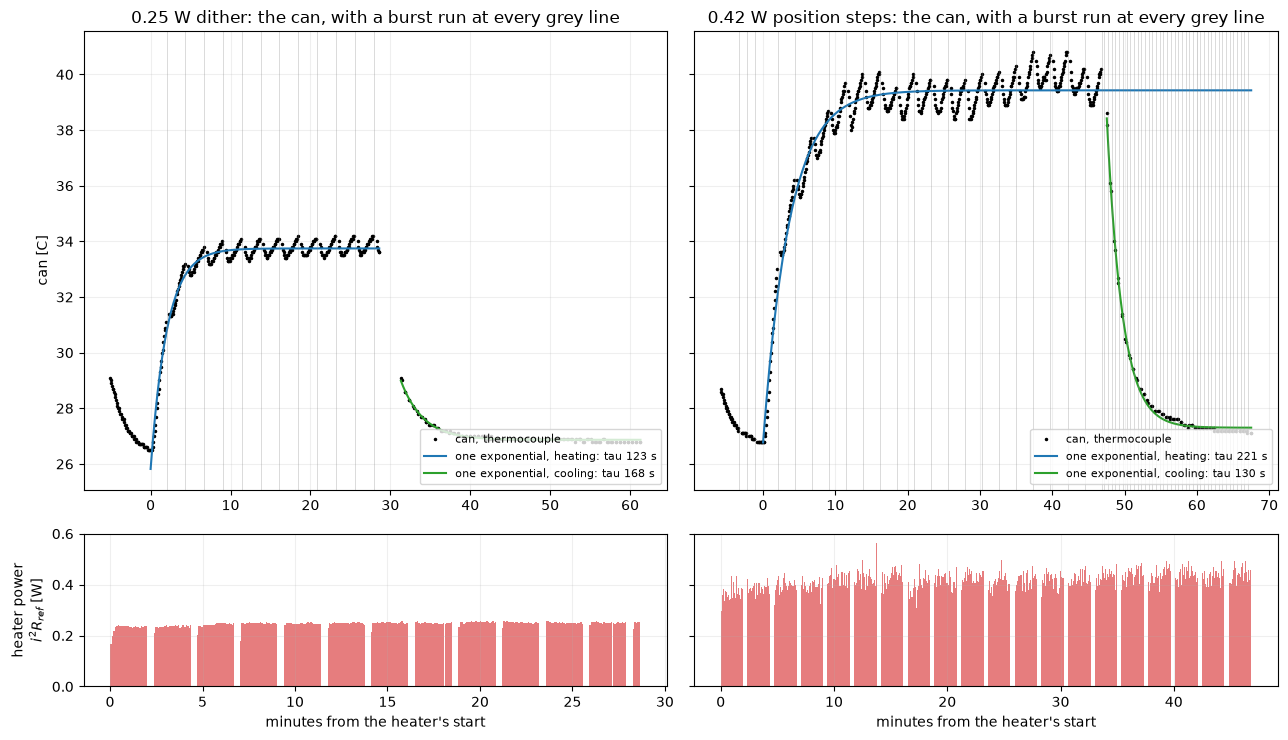

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharey="row", gridspec_kw=dict(height_ratios=[3, 1]))
for j, (cap, ccap, label) in enumerate((("dither/capture-1", "dither/capture-2", "0.25 W dither"),
                                        ("steps/capture-1", "steps/capture-1", "0.42 W position steps"))):
    ax, ap = axes[0, j], axes[1, j]
    h = HEAT[cap]
    t0 = h.unix.iloc[0]
    for c in {cap, ccap}:
        t = CAN[c][~CAN[c].glitch]
        ax.plot((t.unix - t0) / 60, t.can_c, ".", ms=3, color="k", label="can, thermocouple" if c == cap else None)
    for kind, color in (("heat", "tab:blue"), ("cool", "tab:green")):
        ts, f = FITS[(cap, kind)]
        x = np.linspace(0, (CAN[ccap if kind == "cool" else cap].unix.max() - ts), 300)
        y = f["ta"] + f["dt"] * ((1 - np.exp(-x / f["tau"])) if kind == "heat" else np.exp(-x / f["tau"]))
        ax.plot((ts - t0 + x) / 60, y, color=color, lw=1.5, label=f"one exponential, {kind}ing: tau {f['tau']:.0f} s")
    for x in BURSTS[cap].unix:
        ax.axvline((x - t0) / 60, color="grey", lw=0.4, alpha=0.5)
    ax.set_title(f"{label}: the can, with a burst run at every grey line")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, loc="lower right")
    # the heater's power in 5 s bins, with R held at the reference (the model lets it climb)
    win, _ = hc.heat_windows(h, board)
    rref = BLK.loc[cap, "r_ref_ohm"]
    for a, b, q in win:
        ap.fill_between([(a - t0) / 60, (b - t0) / 60], 0, q * rref, color="tab:red", alpha=0.6, lw=0)
    ap.set_ylim(0, 0.6)
    ap.set_xlabel("minutes from the heater's start")
    ap.grid(alpha=0.2)
axes[0, 0].set_ylabel("can [C]")
axes[1, 0].set_ylabel("heater power\n$i^2 R_{ref}$ [W]")
plt.tight_layout()
plt.show()

**What you are looking at.** Top, the can through each block and its cool-down, with one exponential
through the heating and one through the cooling, and a grey line at every burst run. Bottom, the
heater's power in 5 s bins, with the gaps where the burst runs were.

The can dips at every burst break, about half a degree, and recovers when the heater comes back.
That dip is the signature of a node behind the can that stops feeding it the moment the heater
stops, and it is what sets the fast mode in section 4. The dither block's log ends mid-dip, when the
shaft left mid travel, and the cool-down log picks up 162 s later. The steps block's power visibly
climbs through the first 20 minutes, which is the stretched heating curve of the table.

## 3. The winding

The thermometer is copper's handbook line (notebook 17 sec 4) through the block's $R_{ref}$, on the
waveform-fit R of each burst run. The burst runs between the heater's 120 s segments, launched 0.3 s
after the heater's last poll; its from-rest captures land several seconds into the run (the bias
read, the jam check, then the bursts), so the winding has already cooled toward the can for those
seconds when it is read. Section 4 takes that into account; here the readings are shown as they are.

For every run, the winding temperature R implies, the can at the run, and the difference. Then the
same reading for the steps block, where the bursts show something other than temperature, as the
excess of R over what copper predicts from the can and the block's own reference.

In [5]:
def thermometer(cap):
    b = BURSTS[cap].copy()
    blk = BLK.loc[cap]
    b["t_w"] = th.thermometer_c(b.wave_r_ohm, blk.r_ref_ohm, blk.t_ref_c)
    b["over_can"] = b.t_w - b.can_c
    # R over copper's prediction from the can alone (winding at the can), in %
    b["excess_pct"] = (b.wave_r_ohm / th.copper_carry(blk.r_ref_ohm, blk.t_ref_c, b.can_c) - 1) * 100
    return b


TH = {c: thermometer(c) for c in ("rest/capture-1", "dither/capture-1", "dither/capture-2", "steps/capture-1")}
d = TH["dither/capture-1"]
display(d[["k", "phase", "t_s", "can_c", "wave_r_ohm", "wave_r_sd_ohm", "v0_v", "v_over_i_ohm", "t_w", "over_can"]]
        .rename(columns={"t_w": "T(R) C", "over_can": "over the can C"}).round(2).set_index("k"))
heat_runs = d.iloc[1:]                                     # run 0 is the start transient, below
rows = []
for name, g in (("rest bursts (the reference)", TH["rest/capture-1"]), ("0.25 W block, run 0", d.iloc[:1]),
                ("0.25 W block, runs 1-11", heat_runs), ("0.25 W cool-down, 60 runs", TH["dither/capture-2"]),
                ("0.42 W block, its 3 reference runs", TH["steps/capture-1"][TH["steps/capture-1"].phase == "ref"]),
                ("0.42 W block, 20 heat runs", TH["steps/capture-1"][TH["steps/capture-1"].phase == "heat0.4W"]),
                ("0.42 W cool-down, 40 runs", TH["steps/capture-1"][TH["steps/capture-1"].phase == "cool0.4W"])):
    rows.append({"runs": name, "n": len(g), "R mean ohm": g.wave_r_ohm.mean(), "R sd %": g.wave_r_ohm.std() / g.wave_r_ohm.mean() * 100,
                 "T(R) mean C": g.t_w.mean(), "can mean C": g.can_c.mean(), "over the can C": g.over_can.mean(),
                 "+/- (sem)": g.over_can.std() / np.sqrt(len(g)), "R over copper %": g.excess_pct.mean(),
                 "V/I at the limit ohm": g.v_over_i_ohm.mean()})
SUMM = pd.DataFrame(rows).set_index("runs")
display(SUMM.round(2))
P_ON = PLAT["dither/capture-1"]["p_on"]
over = heat_runs.over_can
print(f"0.25 W block, runs 1-11: winding {over.mean():.1f} +/- {over.std() / np.sqrt(len(over)):.1f} C over the can at "
      f"{P_ON:.3f} W -> winding to can {over.mean() / P_ON:.0f} +/- {over.std() / np.sqrt(len(over)) / P_ON:.0f} C/W as read; "
      f"one run's 2% of R is {heat_runs.wave_r_ohm.std() / heat_runs.wave_r_ohm.mean() * (K_CU + heat_runs.t_w.mean()):.1f} C")
print(f"run 0 reads {d.t_w.iloc[0]:.0f} C, {d.over_can.iloc[0]:.0f} C over its can, {d.wave_r_ohm.iloc[0] / heat_runs.wave_r_ohm.mean() * 100 - 100:+.0f}% "
      f"over the other runs' R")

,phase,t_s,can_c,wave_r_ohm,wave_r_sd_ohm,v0_v,v_over_i_ohm,T(R) C,over the can C
k,,,,,,,,,
0,heat0.3W,434.5,31.35,5.39,0.06,-0.18,5.32,62.93,31.58
1,heat0.3W,575.7,33.20,5.07,0.05,-0.12,5.28,45.49,12.29
2,heat0.3W,716.5,33.70,5.10,0.05,-0.17,5.11,47.09,13.39
3,heat0.3W,857.7,33.85,5.17,0.05,-0.14,5.23,50.84,16.99
4,heat0.3W,999.0,33.95,4.92,0.04,-0.11,5.11,37.05,3.10
5,heat0.3W,1140.3,34.00,5.15,0.05,-0.20,4.99,49.79,15.79
6,heat0.3W,1281.5,34.05,5.02,0.06,-0.13,5.13,42.34,8.29
7,heat0.3W,1423.0,34.10,4.94,0.05,-0.12,5.13,38.04,3.94
8,heat0.3W,1564.6,34.05,4.93,0.04,-0.12,5.09,37.32,3.27


,n,R mean ohm,R sd %,T(R) mean C,can mean C,over the can C,+/- (sem),R over copper %,V/I at the limit ohm
runs,,,,,,,,,
rest bursts (the reference),5,4.75,1.49,27.68,26.23,1.45,1.76,0.55,4.84
"0.25 W block, run 0",1,5.39,NaN,62.93,31.35,31.58,NaN,11.88,5.32
"0.25 W block, runs 1-11",11,5.05,1.91,44.01,33.93,10.08,1.62,3.76,5.11
"0.25 W cool-down, 60 runs",60,4.82,1.89,31.23,27.10,4.13,0.65,1.58,4.81
"0.42 W block, its 3 reference runs",3,4.66,1.57,25.59,27.00,-1.41,2.28,-0.54,4.88
"0.42 W block, 20 heat runs",20,5.39,2.87,66.13,39.33,26.81,1.74,9.78,5.43
"0.42 W cool-down, 40 runs",40,5.13,3.26,51.42,28.73,22.69,1.59,8.64,5.26


0.25 W block, runs 1-11: winding 10.1 +/- 1.6 C over the can at 0.245 W -> winding to can 41 +/- 7 C/W as read; one run's 2% of R is 5.3 C
run 0 reads 63 C, 32 C over its can, +7% over the other runs' R


**What you are looking at.** Top, every burst run of the 0.25 W block. Bottom, the same reading
summarised for each group of runs in the dataset, with the run-to-run scatter of R, the mean of the
winding over the can, its standard error, R over copper's prediction from the can alone, and the line
fit's V/I at the current limit as a second route into R.

- **At a quarter watt the winding reads 10 C over the can.** Runs 1 to 11 average 5.047 ohm, 44.0 C,
  against a can at 33.9 C, 10.1 +/- 1.6 C over. Divided by the heater's 0.245 W that is 41 +/- 7 C/W
  as read, before any allowance for the seconds the winding has cooled when the burst catches it.
- **One run is 2% of R, 5 C.** The eleven runs scatter 1.9% in R, 5.3 C of copper at 44 C. The mean of eleven is 1.6 C.
- **Run 0 is a start transient.** 5.39 ohm, 63 C, 32 C over its can, 7% over the other runs, two
  minutes into the block with the can only 5 C up. Notebook 17 sec 5 saw the same kind of excess
  after stalls and a cal; here the servo had just come off the aborted first dither and a re-centre.
  It is left out of every mean and fit.
- **The quarter-watt block left the thermometer 2% high.** Through its 30 minute cool-down the
  bursts read 4.1 +/- 0.7 C over the can, 1.6% of R, with the can within 2 C of room from the fifth
  minute on. The model says the winding is at the can within a minute of the heater stopping (section
  4), so the 4 C is an offset in R, the small cousin of what follows. An hour later the steps block's
  fresh reference read 1% under the carried one, so it had faded.
- **The 0.42 W block's bursts are something else.** During its heating they read 27 C over the
  can, 10% over copper, and through the cool-down 23 C over a can sitting at room, the excess
  scattering 2 to 16% and trending up while the can does not move. The V/I at the limit climbs with
  them, from 4.9 ohm at the reference to 5.3 to 5.4 on average. The bench RCA the same night, over 2000 captures, put the
  excess in the circuit, not in the winding. Every route reads it together, it is flat with current,
  stable inside a burst, it was created by the hard reversals at 0.47 A, and it held for over an hour
  with the can at room. A winding cannot hold heat with its can at room for an hour. So these runs
  say nothing about the winding's temperature, and they are out of every thermal fit below.
  The hold's own free bursts, before and after it, carry the same excess, 3 to 15% over copper.

**The free-burst route is contaminated.** Every free burst's R above is a ratio to a reference read at
a different seat, a different rotor angle with the brushes on different commutator bars, and the
brush contact moves R by percents from seat to seat and for hours after running. So a cross-seat
ratio reads contact steps as temperature, and the free-burst winding numbers of this section carry them. They are the 10 C over the can, the 41 C/W as read, and the 40 to 45 C/W for winding to can the bursts
want in section 4. They are kept and shown because nothing better reads the winding in the free
blocks, not because they are a thermometer. The shipped thermometer reads R only as a same-seat
ratio within one hold for this reason. The locked hold below is a same-seat reading, and the can's
own response needs no R at all.

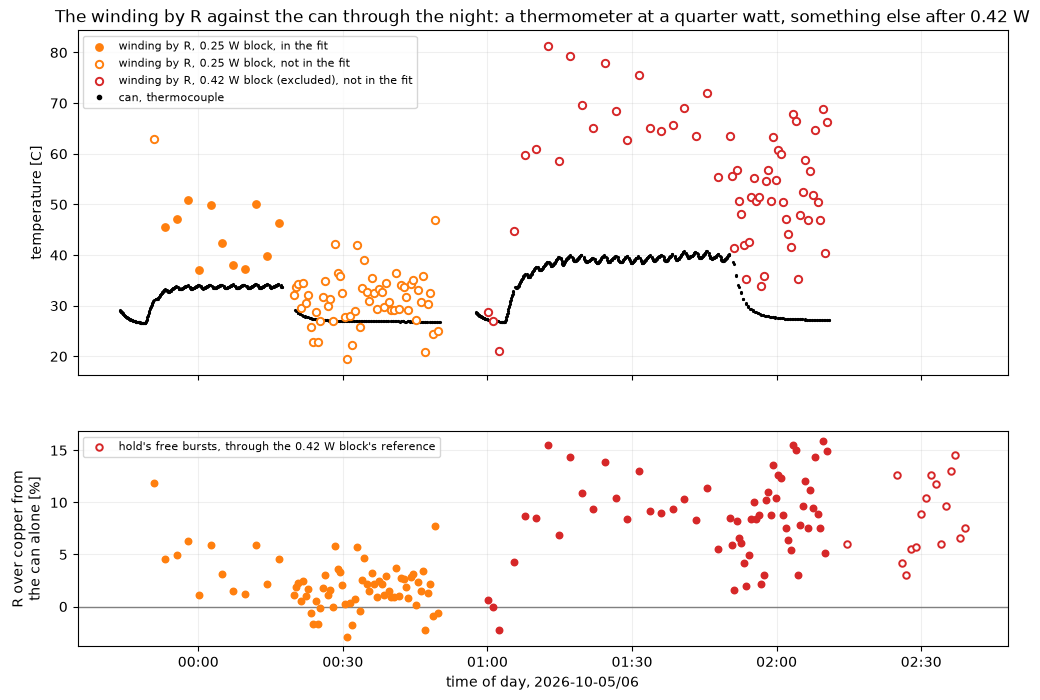

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw=dict(height_ratios=[1.6, 1]))
t0 = HEAT["dither/capture-1"].unix.iloc[0]
for cap, ccap, color, label in (("dither/capture-1", "dither/capture-2", "tab:orange", "0.25 W block"),
                                ("steps/capture-1", "steps/capture-1", "tab:red", "0.42 W block (excluded)")):
    for c in {cap, ccap}:
        t = CAN[c][~CAN[c].glitch]
        a1.plot([clock(u) for u in t.unix], t.can_c, ".", ms=2.5, color="k")
        b = TH[c]
        filled = (c == "dither/capture-1") & (b.k > 0)          # only the 0.25 W block's runs 1-11 enter the fit
        if filled.any():
            a1.scatter([clock(u) for u in b.unix[filled]], b.t_w[filled], s=28, color=color, zorder=3,
                       label=f"winding by R, {label}, in the fit")
        a1.scatter([clock(u) for u in b.unix[~filled]], b.t_w[~filled], s=28, facecolor="white", edgecolor=color, lw=1.4, zorder=3,
                   label=f"winding by R, {label}, not in the fit" if c == ccap else None)
        a2.scatter([clock(u) for u in b.unix], b.excess_pct, s=22, color=color, zorder=3)
# the hold's free bursts, through the steps block's reference (the one taken that hour)
hb = BURSTS["hold/capture-1"].copy()
blk = BLK.loc["steps/capture-1"]
hb["excess_pct"] = (hb.wave_r_ohm / th.copper_carry(blk.r_ref_ohm, blk.t_ref_c, hb.can_c) - 1) * 100
a2.scatter([clock(u) for u in hb.unix], hb.excess_pct, s=22, facecolor="white", edgecolor="tab:red", lw=1.4, zorder=3,
           label="hold's free bursts, through the 0.42 W block's reference")
a1.plot([], [], ".", color="k", label="can, thermocouple")
a1.set_ylabel("temperature [C]")
a1.set_title("The winding by R against the can through the night: a thermometer at a quarter watt, something else after 0.42 W")
a1.legend(fontsize=8, loc="upper left")
a1.grid(alpha=0.2)
a2.axhline(0, color="grey", lw=1)
a2.set_ylabel("R over copper from\nthe can alone [%]")
a2.set_xlabel("time of day, 2026-10-05/06")
a2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=PDT))
a2.legend(fontsize=8, loc="upper left")
a2.grid(alpha=0.2)
plt.show()

**What you are looking at.** Top, the thermocouple through the night with the winding each burst run
implies, filled where the run enters the thermal fit, open where it does not. Bottom, every run's R
over what copper predicts if the winding sat at the can, in percent. Zero is a winding at the can
with a good reference.

Through the 0.25 W block the winding sits a steady 10 C over the can, and through its cool-down it
hugs the can plus the 2% offset. From the 0.42 W block on the lower panel leaves zero and does not
come back. The excess during that block's heating, about 10%, is twice what 10 C of winding over the
can would be, and the climb through the cool-down with the can flat is the part no temperature can do.

### The locked hold

The hold is the one place the winding was read while the current flowed. The firmware's
identification aggregates fold the ON-window current, the terminal difference and the duty into
running means, and their ratio is the `ident resistance` route. Its level is not the burst's. It
takes the commanded window for the drive pulse and its 190-tick windows sit where notebook 16 and
the bench found the current over-read, so I read only its ratio over the hold, as a copper rise from
its own first ten seconds. The excess over the can is that rise less the can's, and one exponential
through its first three minutes gives the winding's own time constant.

,excess plateau C,+/-,tau_w s,+/-,R_wc C/W,C_w J/C
fit window s,,,,,,
120,8.65,0.48,75.25,7.30,31.57,2.38
180,7.32,0.12,56.14,2.56,26.70,2.10
300,6.36,0.04,41.35,1.34,23.18,1.78
600,5.25,0.03,29.51,1.25,19.17,1.54


hold: 0.240 A, 0.274 W by the aggregates; R_agg 4.600 -> 4.783 ohm (+4.0%, 10.4 C of copper) while the can rose 6.4 C; can fit tau 127 s, dT 7.23 C -> 26 C/W can to air
   60 s: winding + 8.8 C, can +2.2 C, excess 6.7 C, current 0.241 A
  120 s: winding +11.0 C, can +3.9 C, excess 7.1 C, current 0.239 A
  180 s: winding +11.2 C, can +4.9 C, excess 6.3 C, current 0.239 A
  300 s: winding +11.0 C, can +5.9 C, excess 5.1 C, current 0.239 A
  450 s: winding +10.7 C, can +6.3 C, excess 4.4 C, current 0.239 A
  590 s: winding +10.4 C, can +6.4 C, excess 4.0 C, current 0.239 A
R_agg noise, 20 s rolling sd after 5 min: 0.25% = 0.6 C


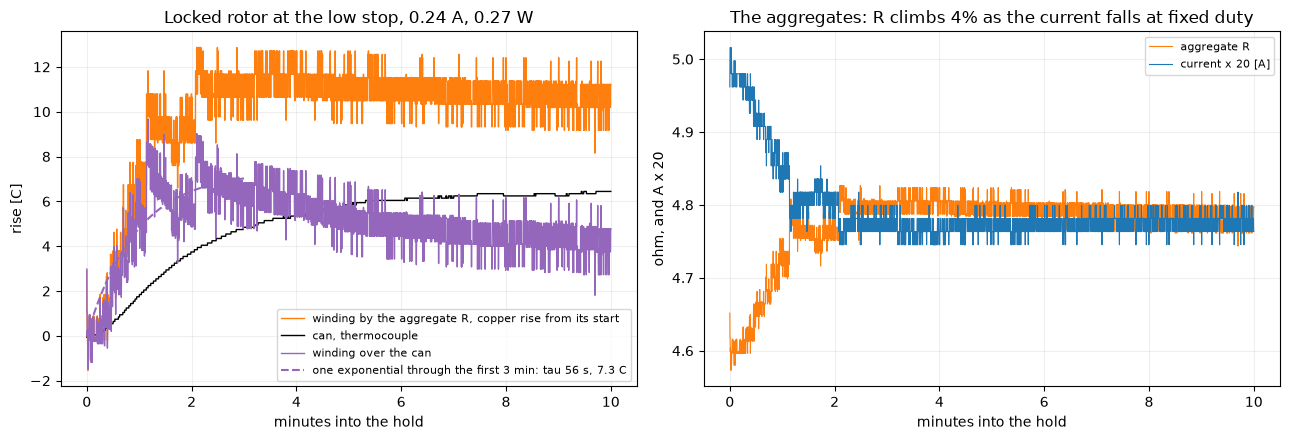

In [7]:
hh = HOLD[(HOLD.phase == "hold") & HOLD.r_agg.notna()].copy()
hh["t"] = hh.unix - hh.unix.iloc[0]
r0 = hh.r_agg[hh.t < 10].mean()
c0 = hh.can_c[hh.t < 10].mean()
hh["dT_w"] = (hh.r_agg / r0 - 1) * (K_CU + c0)             # the winding's rise by copper from its own start
hh["dT_c"] = hh.can_c - c0
hh["excess"] = hh.dT_w - hh.dT_c
P_HOLD = (hh.i_a ** 2 * hh.r_agg).mean()                   # the aggregate's own power, I x V
from scipy.optimize import curve_fit


def rise_from_zero(t, dT, tau):
    # the excess starts at zero by construction (winding and can at the same start), so no offset
    return dT * (1 - np.exp(-t / tau))


def excess_fit(cut):
    m = hh.t <= cut
    p, cov = curve_fit(rise_from_zero, hh.t[m], hh.excess[m], p0=[7.0, 40.0])
    return p, np.sqrt(np.diag(cov))


rows = []
for cut in (120, 180, 300, 600):
    (dT, tau), (dT_se, tau_se) = excess_fit(cut)
    rows.append({"fit window s": cut, "excess plateau C": dT, "+/-": dT_se, "tau_w s": tau, "+/- ": tau_se,
                 "R_wc C/W": dT / P_HOLD, "C_w J/C": tau / (dT / P_HOLD)})
HOLDFIT = pd.DataFrame(rows).set_index("fit window s")
display(HOLDFIT.round(2))
fc = hc.step(hh.t, hh.can_c, "heat")
print(f"hold: {hh.i_a.mean():.3f} A, {P_HOLD:.3f} W by the aggregates; R_agg {r0:.3f} -> {hh.r_agg[hh.t > 580].mean():.3f} ohm "
      f"({(hh.r_agg[hh.t > 580].mean() / r0 - 1) * 100:+.1f}%, {hh.dT_w[hh.t > 580].mean():.1f} C of copper) while the can rose "
      f"{hh.dT_c[hh.t > 580].mean():.1f} C; can fit tau {fc['tau']:.0f} s, dT {fc['dt']:.2f} C -> {fc['dt'] / P_HOLD:.0f} C/W can to air")
for w in (60, 120, 180, 300, 450, 590):
    m = (hh.t >= w) & (hh.t < w + 20)
    print(f"  {w:3d} s: winding +{hh.dT_w[m].mean():4.1f} C, can +{hh.dT_c[m].mean():3.1f} C, excess {hh.excess[m].mean():.1f} C, "
          f"current {hh.i_a[m].mean():.3f} A")
print(f"R_agg noise, 20 s rolling sd after 5 min: {hh.r_agg[hh.t > 300].rolling(100).std().mean() / r0 * 100:.2f}% "
      f"= {hh.r_agg[hh.t > 300].rolling(100).std().mean() / r0 * (K_CU + c0):.1f} C")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(hh.t / 60, hh.dT_w, color="tab:orange", lw=1, label="winding by the aggregate R, copper rise from its start")
a1.plot(hh.t / 60, hh.dT_c, color="k", lw=1, label="can, thermocouple")
a1.plot(hh.t / 60, hh.excess, color="tab:purple", lw=1, label="winding over the can")
(dT, tau), _ = excess_fit(180)
x = np.linspace(0, 180, 100)
a1.plot(x / 60, rise_from_zero(x, dT, tau), "--", color="tab:purple", lw=1.5,
        label=f"one exponential through the first 3 min: tau {tau:.0f} s, {dT:.1f} C")
a1.set_xlabel("minutes into the hold")
a1.set_ylabel("rise [C]")
a1.set_title(f"Locked rotor at the low stop, {hh.i_a.mean():.2f} A, {P_HOLD:.2f} W")
a1.grid(alpha=0.2)
a1.legend(fontsize=8)
a2.plot(hh.t / 60, hh.r_agg, color="tab:orange", lw=0.8, label="aggregate R")
a2.plot(hh.t / 60, hh.i_a * 20, color="tab:blue", lw=0.8, label="current x 20 [A]")
a2.set_xlabel("minutes into the hold")
a2.set_ylabel("ohm, and A x 20")
a2.set_title("The aggregates: R climbs 4% as the current falls at fixed duty")
a2.grid(alpha=0.2)
a2.legend(fontsize=8)
plt.tight_layout()
plt.show()

**What you are looking at.** The table fits one exponential to the winding's excess over the can for
four lengths of window, and reads winding to can and the winding's heat capacity from each. Under it,
the hold's numbers at a few moments, then the plots, the two rises and their difference on the left,
the raw aggregate R and current on the right.

- **The winding climbs 11 C in two minutes and then holds.** R_agg 4.600 to 4.783 ohm, +4.0%, 10.4 C
  of copper, while the can rises 6.4 C over the ten minutes. The current fell 4% at fixed duty to
  make that R, so the rise is model free. The aggregate's own noise is 0.2% over 20 s, half a degree,
  which is the quiet reading the thermometer never gets from a free burst.
- **The winding's time constant is about a minute.** Over the first two minutes the excess over the
  can builds as one exponential with tau 75 +/- 7 s to 8.7 C, over three minutes 56 s to 7.3 C. That
  is 27 to 32 C/W winding to can at 0.274 W, and a heat capacity of 2.1 to 2.4 J/C, five grams or so
  of copper and iron. A real rotor.
- **Then the excess shrinks, 7 C at two minutes to 4 C at ten, at constant power.** A thermal node
  cannot do that. With the heat steady the winding sits a fixed $P R_{wc}$ over the can once it has
  settled, whatever the can does. Two readings fit. (a) The excess state from section 3 was in the
  circuit when the hold started (the free burst before it read 5% over copper) and the hold worked
  it down, which the bench RCA saw too, so part of R's fall is the contact relaxing while copper
  rises. (b) Something in the aggregate route moves with the warming servo. The hold cannot separate
  them and Open has the experiment. The longer fit windows in the table are pulled down by it, so the
  two-minute and three-minute rows are the ones I read.
- **The can's fitted rise is 7.2 C for 0.274 W, 26 C/W,** against 30 to 37 in the free blocks. The
  free heaters put in more heat than $i^2 R$. Their applied duty times the rail times the current
  comes to 0.34 and 0.50 W against 0.25 and 0.42 of winding heat, and after the bridge and shunt
  that leaves 0.05 to 0.07 W of back-EMF and brush work turning into heat in the gears and brushes.
  The locked hold does no work. Counting that heat brings the free blocks' can to air down to 23 to
  28 C/W by the heater's own time and 27 to 33 on the wall clock, straddling the hold's 26. The next
  cell shows the sum, and the model in section 4 does not count it, so its $R_{ca}$ is per watt of
  winding heat with the servo moving the way these heaters moved it.

In [8]:
rows = []
for cap in ("dither/capture-1", "steps/capture-1"):
    h, t = HEAT[cap], CAN[cap]
    rail = np.interp(h.unix, t.unix, t.rail_v)             # the rail from the 5 s log, at each poll
    i = h.i_hat * board.a_per_count
    v = h.duty_applied.abs() / 32767 * rail                 # the applied voltage, duty times the rail
    p_in = (v * i.abs()).mean()
    p_cu = (i ** 2).mean() * BLK.loc[cap, "r_ref_ohm"]
    p_bridge = (i ** 2).mean() * 0.4                        # two Rds, the shunt and the sagging source, about 0.4 ohm
    rise = PLAT[cap]["plateau"] - PLAT[cap]["start"]
    rows.append({"block": cap, "duty x rail x |i| W": p_in, "i^2 R_ref W": p_cu, "i^2 x 0.4 ohm (bridge, shunt) W": p_bridge,
                 "left for back-EMF and brushes W": p_in - p_cu - p_bridge, "share of winding heat %": (p_in - p_cu - p_bridge) / p_cu * 100,
                 "R_ca by all heat but the bridge, on time": rise / (p_in - p_bridge),
                 "R_ca by all heat but the bridge, wall": rise / (p_in - p_bridge) / (TL.loc[cap, "on %"] / 100)})
display(pd.DataFrame(rows).set_index("block").round(3))

,duty x rail x |i| W,i^2 R_ref W,"i^2 x 0.4 ohm (bridge, shunt) W",left for back-EMF and brushes W,share of winding heat %,"R_ca by all heat but the bridge, on time","R_ca by all heat but the bridge, wall"
block,,,,,,,
dither/capture-1,0.337,0.246,0.021,0.069,28.137,23.063,27.105
steps/capture-1,0.502,0.419,0.036,0.048,11.448,27.905,32.674


**What you are looking at.** The electrical input to the motor against the winding's $i^2 R$, per
block, and what is left after a rough bridge and shunt allowance, then the can to air each block
gives if all of it heats the servo. The product of two polled averages is rough, duty times rail is
the applied voltage only on average, and 0.4 ohm for the bridge is a guess from the burst reports'
"sagging 0.33 ohm", so this is a size, not a number. It says the free heaters put 10 to 30% more heat
into the servo than their winding heat, which is enough to close most of the gap to the hold.

## 4. The model

Now the two-node fit through everything at once. The data in it is the can through the 0.25 W block
and its cool-down, the can through the 0.42 W block and its cool-down, and the winding by R from the
eleven heat runs of the 0.25 W block. The heat is each block's own poll, 5 s bins of $i_{hat}^2$
with nothing in the burst breaks, times $R(T_w)$ on copper from the block's reference, so the model's
power climbs as its winding warms the way the real one did. The state starts at the rested can,
winding and can together, and the ambient starts there too, with a free slope per block, because a
servo that has rested on the bench is at the room's temperature and the room drifts.

That anchor matters more than it sounds. With the ambient free the fit uses it to reshape the curves and lands on a winding of 0.2 J/C,
under a gram of copper, at over 100 C/W. The row "ambient free" below is that fit, kept for the
record.

The weights are 0.2 C on the can, about its scatter around the fitted curves with the room's AC
cycling in it, and 5 C on each burst run, section 3's one-run scatter. The burst's winding is read
8 s after the run was launched, with 4 and 12 s as variations. Then the variations that show what
is pinned and what is not. The can alone. The eleven runs weighed at their mean's 1.5 C instead of
5. Winding to can fixed at the bursts' 40 C/W with 1.0 J/C, and at the hold's 25 C/W with 0.9 J/C,
to see whether the can can tell. The uncertainties are the fit's own standard errors.

In [9]:
BURST_AT = 8.0                                 # s from the run's launch to its from-rest captures
SIG_CAN, SIG_W = 0.2, 5.0                      # the weights, C


def assemble(caps, heat_phase):
    # one block: the can rows from the rested start on, its heat windows, and the rested start itself
    can, win = [], []
    for c in caps:
        t = CAN[c]
        can.append(t[~t.glitch][["unix", "can_c", "phase"]])
        if c in HEAT and len(HEAT[c]):
            w, _ = hc.heat_windows(HEAT[c], board)
            win += w
    can = pd.concat(can).sort_values("unix").reset_index(drop=True)
    start = win[0][0] - 1.0                                  # a second before the heater's first poll
    pre = can[can.unix < start]
    x0 = pre.can_c.iloc[-3:].mean()                          # the rested can: winding, can and room together
    return dict(can=can[can.unix >= start].reset_index(drop=True), win=win, start=start, x0=x0)


A = assemble(["dither/capture-1", "dither/capture-2"], "heat0.3W")
B = assemble(["steps/capture-1"], "heat0.4W")
A.update(r_ref=BLK.loc["dither/capture-1", "r_ref_ohm"], t_ref=BLK.loc["dither/capture-1", "t_ref_c"])
B.update(r_ref=BLK.loc["steps/capture-1", "r_ref_ohm"], t_ref=BLK.loc["steps/capture-1", "t_ref_c"])
W = TH["dither/capture-1"].iloc[1:]                          # the eleven heat runs
print(f"block A: {len(A['can'])} can readings, {len(A['win'])} heat windows, starts at {A['x0']:.2f} C; "
      f"block B: {len(B['can'])} can readings, {len(B['win'])} heat windows, starts at {B['x0']:.2f} C; {len(W)} winding runs")

NAMES = ["cw", "cc", "rwc", "rca", "tbA", "tbB", "taA", "taB"]


def run(net, blk, t_obs, ta0, tb):
    return net.run(blk["start"], (blk["x0"], blk["x0"], ta0), blk["win"], t_obs, blk["r_ref"], blk["t_ref"], tb=tb)


def residuals(q, use_w=True, sig_w=SIG_W, burst_at=BURST_AT):
    net = th.TwoNode(q["cw"], q["cc"], q["rwc"], q["rca"], 1.0)
    out = []
    _, tc, _ = run(net, A, A["can"].unix.to_numpy(), q["taA"], q["tbA"] * 1e-4)
    out.append((tc - A["can"].can_c.to_numpy()) / SIG_CAN)
    if use_w:
        tw, _, _ = run(net, A, W.unix.to_numpy() + burst_at, q["taA"], q["tbA"] * 1e-4)
        out.append((tw - W.t_w.to_numpy()) / sig_w)
    _, tc, _ = run(net, B, B["can"].unix.to_numpy(), q["taB"], q["tbB"] * 1e-4)
    out.append((tc - B["can"].can_c.to_numpy()) / SIG_CAN)
    return np.concatenate(out)


P0 = dict(cw=1.0, cc=5.0, rwc=40.0, rca=33.0, tbA=0.0, tbB=0.0, taA=A["x0"], taB=B["x0"])
LO = dict(cw=0.05, cc=0.5, rwc=2.0, rca=5.0, tbA=-30, tbB=-30, taA=24.0, taB=24.0)
HI = dict(cw=20.0, cc=100.0, rwc=300.0, rca=100.0, tbA=30, tbB=30, taA=30.0, taB=30.0)


def fit(label, fixed=None, free_ta=False, **kw):
    # Least squares over the parameters not in `fixed`; the ambient's start is the rested can
    # unless `free_ta`. Returns the parameters, their standard errors and the rms per observable.
    fixed = dict(fixed or {})
    if not free_ta:
        fixed.update(taA=A["x0"], taB=B["x0"])
    names = [n for n in NAMES if n not in fixed]

    def f(p):
        q = dict(zip(names, p))
        q.update(fixed)
        return residuals(q, **kw)

    r = least_squares(f, [P0[n] for n in names], bounds=([LO[n] for n in names], [HI[n] for n in names]), x_scale="jac")
    dof = max(1, len(r.fun) - len(r.x))
    cov = np.linalg.pinv(r.jac.T @ r.jac) * (r.fun @ r.fun) / dof
    q = dict(zip(names, r.x))
    q.update(fixed)
    se = dict(zip(names, np.sqrt(np.diag(cov))))
    net = th.TwoNode(q["cw"], q["cc"], q["rwc"], q["rca"], 1.0)
    fast, slow = net.modes()
    nA, nW = len(A["can"]), len(W) if kw.get("use_w", True) else 0
    tw, tc, _ = run(net, A, W.unix.to_numpy() + kw.get("burst_at", BURST_AT), q["taA"], q["tbA"] * 1e-4)
    row = {"fit": label, "C_w J/C": q["cw"], "+/-": se.get("cw", 0), "C_c J/C": q["cc"], "+/- ": se.get("cc", 0),
           "R_wc C/W": q["rwc"], " +/-": se.get("rwc", 0), "R_ca C/W": q["rca"], "  +/-": se.get("rca", 0),
           "room A C": q["taA"], "A C/h": q["tbA"] * 1e-4 * 3600, "room B C": q["taB"], "B C/h": q["tbB"] * 1e-4 * 3600,
           "fast s": fast, "slow s": slow, "rms can A": np.std(r.fun[:nA]) * SIG_CAN,
           "rms winding": np.std(r.fun[nA:nA + nW]) * kw.get("sig_w", SIG_W) if nW else np.nan,
           "rms can B": np.std(r.fun[-len(B["can"]):]) * SIG_CAN,
           "model winding over can at the bursts C": np.mean(tw - tc)}
    return q, se, row


RES = []
MODELS = {}
for label, kw in (("anchored room, all data", {}),
                  ("can only", dict(use_w=False)),
                  ("winding runs weighed at 1.5 C", dict(sig_w=1.5)),
                  ("bursts read 4 s in", dict(burst_at=4.0)),
                  ("bursts read 12 s in", dict(burst_at=12.0)),
                  ("R_wc 40, C_w 1.0 held (the bursts' numbers)", dict(fixed=dict(rwc=40.0, cw=1.0))),
                  ("R_wc 25, C_w 0.9 held (the hold's numbers)", dict(fixed=dict(rwc=25.0, cw=0.9))),
                  ("ambient free", dict(free_ta=True))):
    q, se, row = fit(label, **kw)
    MODELS[label] = q
    RES.append(row)
RES = pd.DataFrame(RES).set_index("fit")
display(RES.round(2))
Q = MODELS["anchored room, all data"]
print(f"data: winding over the can at the bursts {W.over_can.mean():.1f} +/- {W.over_can.std() / np.sqrt(len(W)):.1f} C")
print(f"anchored fit: winding over the air {Q['rwc'] + Q['rca']:.0f} C/W; R_wc x C_w {Q['rwc'] * Q['cw']:.0f} s, R_ca x C_c {Q['rca'] * Q['cc']:.0f} s")
# what each model has the winding at over the can while the heater still runs, 2 s before each stop
stops = np.array([b for _, b, _ in A["win"]])
stops = stops[np.r_[np.diff(stops) > 30, True]] - 2.0        # the last window before each burst break
for label in ("anchored room, all data", "R_wc 40, C_w 1.0 held (the bursts' numbers)"):
    q = MODELS[label]
    tw, tc, _ = run(th.TwoNode(q["cw"], q["cc"], q["rwc"], q["rca"], 1.0), A, stops, q["taA"], q["tbA"] * 1e-4)
    print(f"{label}: winding over the can in heat, 2 s before the heater stops, {np.mean(tw - tc):.1f} C")

block A: 415 can readings, 305 heat windows, starts at 26.50 C; block B: 560 can readings, 499 heat windows, starts at 26.80 C; 11 winding runs


,C_w J/C,+/-,C_c J/C,+/-,R_wc C/W,+/-,R_ca C/W,+/-,room A C,A C/h,room B C,B C/h,fast s,slow s,rms can A,rms winding,rms can B,model winding over can at the bursts C
fit,,,,,,,,,,,,,,,,,,
"anchored room, all data",1.30,0.53,2.22,1.11,28.00,2.93,31.97,0.12,26.50,0.56,26.80,0.37,20.05,128.92,0.25,5.27,0.23,5.50
can only,1.30,0.69,2.24,1.42,27.47,3.11,32.00,0.13,26.50,0.56,26.80,0.36,19.85,129.34,0.25,NaN,0.23,5.37
winding runs weighed at 1.5 C,1.34,0.08,1.83,0.21,34.66,2.23,31.67,0.10,26.50,0.58,26.80,0.37,21.48,125.60,0.25,5.29,0.23,7.09
bursts read 4 s in,1.30,0.59,2.23,1.22,27.94,2.99,31.97,0.12,26.50,0.56,26.80,0.37,20.03,128.96,0.25,5.27,0.23,6.08
bursts read 12 s in,1.30,0.49,2.21,1.03,28.05,2.89,31.97,0.12,26.50,0.56,26.80,0.37,20.06,128.90,0.25,5.26,0.23,5.01
"R_wc 40, C_w 1.0 held (the bursts' numbers)",1.00,0.00,2.34,0.03,40.00,0.00,31.39,0.04,26.50,0.61,26.80,0.39,24.41,120.55,0.25,5.28,0.24,8.13
"R_wc 25, C_w 0.9 held (the hold's numbers)",0.90,0.00,3.12,0.03,25.00,0.00,32.13,0.04,26.50,0.54,26.80,0.34,16.71,134.87,0.25,5.25,0.24,4.39
ambient free,0.21,0.01,4.32,0.08,105.60,5.07,27.72,0.26,27.46,-0.76,26.98,0.31,20.74,126.73,0.14,5.33,0.21,20.29


data: winding over the can at the bursts 10.1 +/- 1.6 C
anchored fit: winding over the air 60 C/W; R_wc x C_w 36 s, R_ca x C_c 71 s
anchored room, all data: winding over the can in heat, 2 s before the heater stops, 5.8 C
R_wc 40, C_w 1.0 held (the bursts' numbers): winding over the can in heat, 2 s before the heater stops, 8.2 C


**What you are looking at.** One fit per row. The four thermal constants with their standard errors,
the fitted room at each block's start and its drift, the network's two modes, the rms against each
observable, and what the model puts the winding at over the can at the moments the bursts read it,
against the data's 10.1 +/- 1.5 C.

- **Can to air and the slow mode are pinned.** $R_{ca}$ is 32.0 +/- 0.1 C/W and does not move across
  the anchored rows, 31.4 to 32.1. The slow mode is 121 to 135 s. Both blocks fit to 0.23 to 0.25 C
  rms, with the AC cycle and the thermocouple's steps in that number. The room drifts +0.3 to
  +0.6 C/h in both blocks, which the hour-later rest readings agree with.
- **The fast mode is in the can data.** 17 to 24 s in every anchored row, with the winding runs or
  without them. It is the half-degree dip at every burst break from section 2, the node behind the
  can that stops feeding it. The can alone cannot say what that node's resistance and capacity are
  separately, only their product. Hold winding to can at 25 or at 40 C/W and the can fits exactly as
  well, 0.25 C, with the can's own capacity moving from 3.1 to 2.3 J/C to keep the modes.
- **Winding to can is where the data runs out.** The free fit says 28 +/- 3 C/W and 1.3 +/- 0.5 J/C,
  and puts the winding 5.5 C over the can at the bursts where the bursts read 10, and 6 C while the
  heater still runs. Weigh the eleven runs at their mean's 1.5 C and it moves to 35 C/W, 7 C at the
  bursts. Hold 40 C/W and the model reaches 8 C at the bursts and about the same in heat, since at
  the break the can cools along with the winding. The bursts want 40 to 45, the hold's
  own curve said 27 to 32 in the excess state, and the can is indifferent. So the honest bracket is
  28 to 45 C/W, with the heat capacity following it through the 20 to 30 s product, 1.3 J/C down to
  about 0.7. The fit's standard error on $R_{wc}$ is not the uncertainty, the spread across these
  rows is.
- **The burst timing hardly matters.** 4 s or 12 s moves the winding at the bursts by half a degree
  and nothing else.
- **The ambient free is a trap.** 0.21 J/C and 106 C/W, with the room fitted
  a degree above the rested can at the start, so the can starts below the room it supposedly rested
  in. Better rms on the can, 0.14 C, bought with an unphysical rotor, which is why the room is
anchored. Nothing thermal here is slower than 135 s, so an R that decays far slower than that
after a heat, such as the 720 s decay measured on this servo after an earlier heat run, is not
heat. It is section 3's circuit excess.

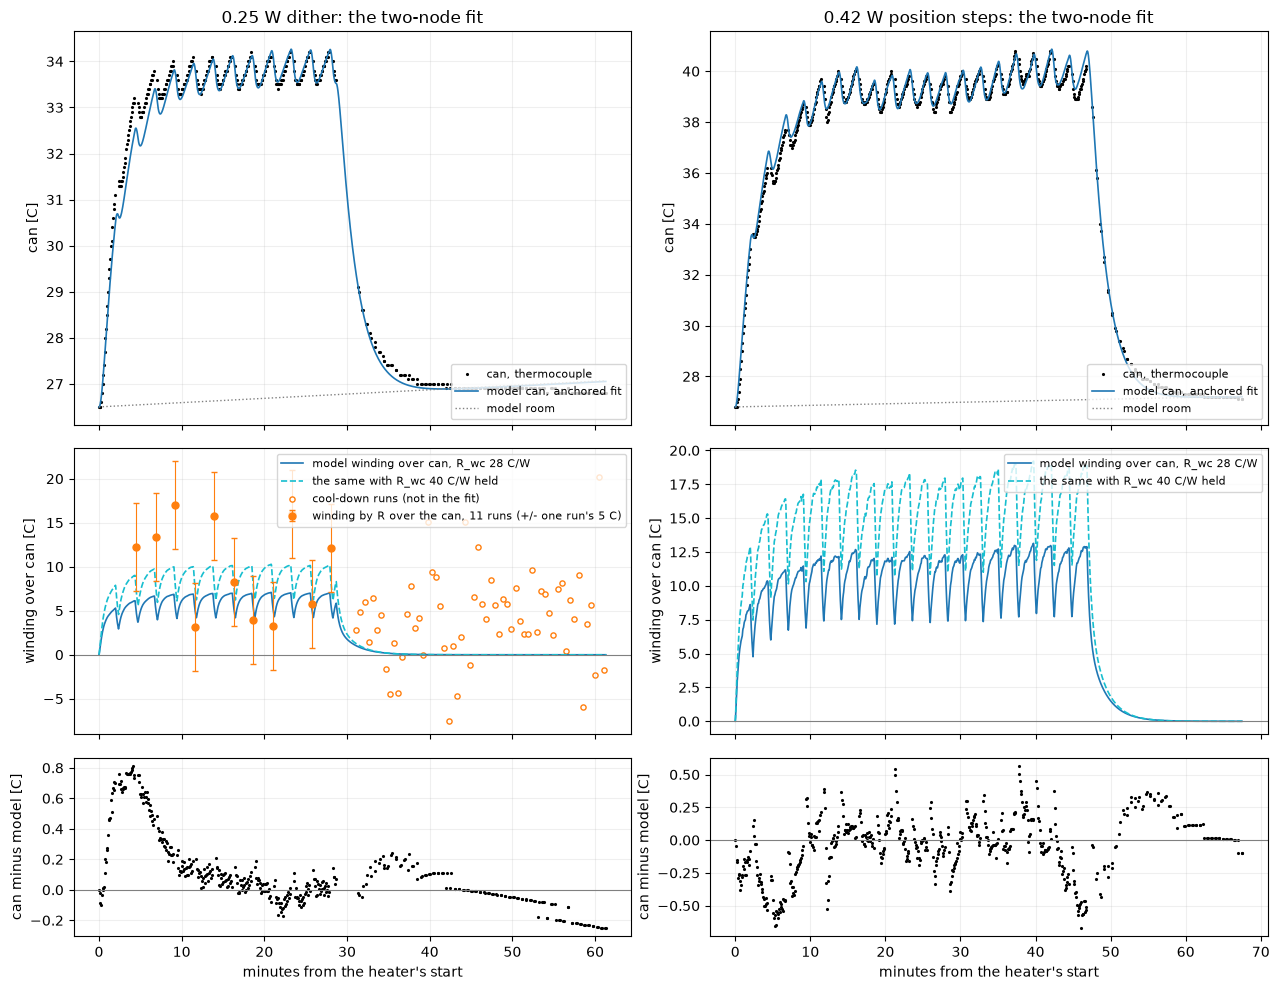

,"heating tau, data s","model, real power s","model, steady power s","cooling tau, data s","model, same log start s"
block,,,,,
0.25 W dither,123.0,172.0,144.0,168.0,107.0
0.42 W steps,221.0,205.0,145.0,130.0,129.0


In [10]:
net = th.TwoNode(Q["cw"], Q["cc"], Q["rwc"], Q["rca"], 1.0)
net40 = th.TwoNode(1.0, MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]["cc"], 40.0,
                   MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]["rca"], 1.0)
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex="col", gridspec_kw=dict(height_ratios=[2.2, 1.6, 1]))
for j, (blk, label, wruns, q40) in enumerate(((A, "0.25 W dither", W, MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]),
                                              (B, "0.42 W position steps", None, MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]))):
    ta, tb = (Q["taA"], Q["tbA"]) if j == 0 else (Q["taB"], Q["tbB"])
    ta40, tb40 = (q40["taA"], q40["tbA"]) if j == 0 else (q40["taB"], q40["tbB"])
    t_obs = np.arange(blk["start"], blk["can"].unix.max(), 2.0)
    tw, tc, tair = run(net, blk, t_obs, ta, tb * 1e-4)
    tw40, tc40, _ = run(net40, blk, t_obs, ta40, tb40 * 1e-4)
    x = (t_obs - blk["start"]) / 60
    a0, a1, a2 = axes[:, j]
    a0.plot((blk["can"].unix - blk["start"]) / 60, blk["can"].can_c, ".", ms=2.5, color="k", label="can, thermocouple")
    a0.plot(x, tc, color="tab:blue", lw=1.2, label="model can, anchored fit")
    a0.plot(x, tair, color="grey", lw=1, ls=":", label="model room")
    a0.set_title(f"{label}: the two-node fit")
    a0.set_ylabel("can [C]")
    a0.legend(fontsize=8, loc="lower right")
    a0.grid(alpha=0.2)
    a1.plot(x, tw - tc, color="tab:blue", lw=1.2, label=f"model winding over can, R_wc {Q['rwc']:.0f} C/W")
    a1.plot(x, tw40 - tc40, color="tab:cyan", lw=1.2, ls="--", label="the same with R_wc 40 C/W held")
    if wruns is not None:
        a1.errorbar((wruns.unix + BURST_AT - blk["start"]) / 60, wruns.over_can, yerr=5.0, fmt="o", ms=5, color="tab:orange",
                    ecolor="tab:orange", elinewidth=0.8, capsize=2, label="winding by R over the can, 11 runs (+/- one run's 5 C)")
        cool = TH["dither/capture-2"]
        a1.scatter((cool.unix + BURST_AT - blk["start"]) / 60, cool.over_can, s=14, facecolor="white", edgecolor="tab:orange", lw=1,
                   label="cool-down runs (not in the fit)")
    a1.axhline(0, color="grey", lw=0.8)
    a1.set_ylabel("winding over can [C]")
    a1.legend(fontsize=8, loc="upper right")
    a1.grid(alpha=0.2)
    _, tcd, _ = run(net, blk, blk["can"].unix.to_numpy(), ta, tb * 1e-4)
    a2.plot((blk["can"].unix - blk["start"]) / 60, blk["can"].can_c - tcd, ".", ms=2.5, color="k")
    a2.axhline(0, color="grey", lw=0.8)
    a2.set_ylabel("can minus model [C]")
    a2.set_xlabel("minutes from the heater's start")
    a2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# the fitted model's own curves, fitted with one exponential the way section 2 fitted the data
rows = []
for blk, cap, label in ((A, "dither/capture-1", "0.25 W dither"), (B, "steps/capture-1", "0.42 W steps")):
    ta, tb = (Q["taA"], Q["tbA"]) if blk is A else (Q["taB"], Q["tbB"])
    t_end = blk["win"][-1][1]
    s = blk["can"][(blk["can"].unix <= t_end)]
    _, tc, _ = run(net, blk, s.unix.to_numpy(), ta, tb * 1e-4)
    fm, fd = hc.step(s.unix - blk["win"][0][0], tc, "heat"), hc.step(s.unix - blk["win"][0][0], s.can_c, "heat")
    i2 = np.mean([q for _, _, q in blk["win"]])
    flat = [(a, b, i2) for a, b, _ in blk["win"]]           # the same on-off pattern at the block's mean current
    _, tcf, _ = net.run(blk["start"], (blk["x0"],) * 3, flat, s.unix.to_numpy(), blk["r_ref"], blk["t_ref"], tb=tb * 1e-4)
    ff = hc.step(s.unix - blk["win"][0][0], tcf, "heat")
    ts, fdc = FITS[(cap, "cool")]
    sc = blk["can"][blk["can"].unix >= ts]
    _, tcc, _ = run(net, blk, sc.unix.to_numpy(), ta, tb * 1e-4)
    fmc = hc.step(sc.unix - ts, tcc, "cool")
    rows.append({"block": label, "heating tau, data s": fd["tau"], "model, real power s": fm["tau"], "model, steady power s": ff["tau"],
                 "cooling tau, data s": fdc["tau"], "model, same log start s": fmc["tau"]})
display(pd.DataFrame(rows).set_index("block").round(0))

**What you are looking at.** Per block, top, the can and the anchored model with its fitted room.
Middle, the model's winding over the can, with the same for winding to can held at 40 C/W, and in the
left panel the eleven heat runs with one run's 5 C as the bar, and the cool-down runs open. Bottom,
the can minus the model. Then the model's own curves fitted with one exponential the way section 2
fitted the data.

The model follows both blocks through the heating, the breaks and the cool-downs with one set of
constants, to a quarter degree rms with the room's AC cycle in it. It is not a perfect fit. On the
quarter-watt block the can climbs faster than the model for the first five minutes, up to 0.8 C
ahead of it, and at the end of that block's cool-down it sits 0.2 C under a model whose room is
still drifting up. On the 0.42 W block the residual stays inside half a degree with the AC cycle's
shape in it. The winding panel is the whole $R_{wc}$ question in one picture. The fitted curve runs
under the eleven runs, the 40 C/W curve runs through them, and the bars cover both. The cool-down
runs sit a steady 4 C above either curve, the 2% offset.

The last table is the check I wanted from section 2. Fed the 0.42 W block's real power profile, the
model's can gives a one-exponential time constant of 205 s against the data's 221, and fed a steady
power on the same on-off pattern 145. So that block's long heating curve is its heater turning up,
not the servo, and the model has it. The dither block is the other way. The model gives 172 s
against the data's 123, with 144 at steady power, and from the same late log start its cool-down
decays at 107 s against the data's 168. So the quarter-watt block's can moves faster than the
network on the way up and slower on the way down, which is what the residual plot shows, and a
two-node network fitted to both blocks cannot do both. Open has the candidates.

### What the model predicts

With the constants in hand the model can run cases the bench did not. Two of them matter to the
firmware. A stall at the 280-count current limit, which the servo will sit in for as long as the user
holds a load, and a hard stall with the limiter out of the way, which is the failure the thermometer
is there to catch. The limiter case is constant current, and the model takes it directly. The hard
stall is constant voltage, the rail across the winding, so the current falls as the winding warms,
$I = V / R(T_w)$, and I step that one with a plain Euler loop at 10 ms.

The winding limit is an assumption. The MG90's magnet wire has no datasheet, and 130 C is the common
enamel class for small motors, so the time to 130 C from a 27 C start is the number, with the
bracket over winding to can from the table above and the winding's heat capacity following it.

In [11]:
T_ROOM, T_LIMIT, V_RAIL = 27.0, 130.0, 7.43                # a rested servo, the assumed enamel class, the pack at the end of the night
R_REF, T_REF = BLK.loc["dither/capture-1", "r_ref_ohm"], BLK.loc["dither/capture-1", "t_ref_c"]
I_LIMIT = 280 * board.a_per_count
CASES = {"anchored fit": (Q["cw"], Q["cc"], Q["rwc"], Q["rca"]),
         "R_wc 40 held": (1.0, MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]["cc"], 40.0, MODELS["R_wc 40, C_w 1.0 held (the bursts' numbers)"]["rca"]),
         "R_wc 25 held": (0.9, MODELS["R_wc 25, C_w 0.9 held (the hold's numbers)"]["cc"], 25.0, MODELS["R_wc 25, C_w 0.9 held (the hold's numbers)"]["rca"])}


def hard_stall(cw, cc, rwc, rca, v=V_RAIL, dt=0.01, t_end=120.0):
    # constant voltage across the winding: I falls as R(T_w) climbs; the bridge's 0.4 ohm left out
    tw = tc = T_ROOM
    out = []
    for n in range(int(t_end / dt)):
        r = th.copper_ohm(tw, R_REF, T_REF)
        p = v * v / r
        q = (tw - tc) / rwc
        tw += dt * (p - q) / cw
        tc += dt * (q - (tc - T_ROOM) / rca) / cc
        out.append((n * dt, tw, tc, p))
    return np.array(out)


rows = []
for name, (cw, cc, rwc, rca) in CASES.items():
    net_ = th.TwoNode(cw, cc, rwc, rca, 1.0)
    t = np.arange(1.0, 3600.0, 1.0)
    tw, tc, _ = net_.run(0.0, (T_ROOM,) * 3, [(0.0, 1e5, I_LIMIT ** 2)], t, R_REF, T_REF)
    hs = hard_stall(cw, cc, rwc, rca)
    hit = hs[hs[:, 1] >= T_LIMIT]
    rows.append({"constants": name, "winding over air per W, C/W": rwc + rca, "can over air per W": rca,
                 f"stall at the {I_LIMIT:.3f} A limit: winding C": tw[-1], "can C": tc[-1], "winding at 60 s": tw[59],
                 f"hard stall at {V_RAIL} V: P at start W": hs[0, 3], "winding at 5 s": hs[int(5 / 0.01), 1],
                 "winding at 10 s": hs[int(10 / 0.01), 1], f"s to {T_LIMIT:.0f} C": hit[0, 0] if len(hit) else np.nan,
                 "can then C": hit[0, 2] if len(hit) else np.nan, "steady winding if it survived C": hs[-1, 1]})
PRED = pd.DataFrame(rows).set_index("constants")
display(PRED.round(1))
print(f"R at 27 C {th.copper_ohm(T_ROOM, R_REF, T_REF):.2f} ohm, at {T_LIMIT:.0f} C {th.copper_ohm(T_LIMIT, R_REF, T_REF):.2f} ohm; "
      f"the hard stall's current falls from {V_RAIL / th.copper_ohm(T_ROOM, R_REF, T_REF):.2f} to {V_RAIL / th.copper_ohm(T_LIMIT, R_REF, T_REF):.2f} A on the way")

,"winding over air per W, C/W",can over air per W,stall at the 0.253 A limit: winding C,can C,winding at 60 s,hard stall at 7.43 V: P at start W,winding at 5 s,winding at 10 s,s to 130 C,can then C,steady winding if it survived C
constants,,,,,,,,,,,
anchored fit,60.0,32.0,46.5,37.4,35.2,11.6,65.9,95.9,17.4,40.7,285.3
R_wc 40 held,71.4,31.4,50.6,37.4,37.7,11.6,76.9,114.5,12.5,33.9,327.1
R_wc 25 held,57.1,32.1,45.5,37.4,35.9,11.6,79.5,115.2,12.7,35.8,278.4


R at 27 C 4.74 ohm, at 130 C 6.64 ohm; the hard stall's current falls from 1.57 to 1.12 A on the way


**What you are looking at.** One row per set of constants, the steady rise per watt, the stall at
the current limit after an hour, and the hard stall's first seconds.

- **The limiter holds the winding near 50 C.** At 0.253 A the winding's own heat is 0.3 W rising to
  a third of a watt as it warms, and it settles at 46 to 51 C with the can at 37, 20 to 24 C over the
  room. That is a long way from any enamel limit, and the current limit is what the firmware runs by
  default, so the everyday servo is thermally safe by this model whatever the user does to the horn.
- **A hard stall crosses 130 C in 12 to 17 s.** With 7.43 V across 4.74 ohm the winding takes 11.6 W
  at the start, reads 66 to 80 C at five seconds and 96 to 115 at ten. The can is 7 to 14 C up when
  the winding passes 130 C, which a can sensor with its own lag would barely have noticed, so the
  thermometer has to be the sensor, and its 20 to 30 s mode means the first ten seconds are a race
  the firmware's current limit wins and nothing else does. The runaway steady state in the last
  column is the model stretched far past where it was fitted and is there as a size, not a
  prediction.
- **The validity envelope.** Free air on this mount, the can 26 to 41 C, 0.25 to 0.42 W with the
  shaft moving as these heaters moved it, one locked quarter watt. Everything past 13 C of can rise
  is linear extrapolation. A horn or an arm on the output is a radiator the model has not seen, and
  so is a servo clamped into a bracket. The constants are a motor family's. The MG90's ship as defaults in `ident::thermometer` (next
  section), `osc ident thermal` is the stage that refines the gain $g$ per unit, and this notebook
  is what that stage should reproduce.
- **The error bars, honestly.** The thermocouple bead is taped to the outside of the can in room
  air, so it reads somewhere between the can and the air, which under-reads the can's rise and so
  under-reads $R_{ca}$ and over-reads $R_{wc}$ by the same degrees. The winding over the air, 60 to 77
  C/W, does not care where the bead sits, because the winding is read by its own copper and the air
  by the rested can. The 2% burst scatter is 5 C a run and 1.5 C on the eleven, and the reference it
  all hangs on is a median of five rest bursts at 1.5% each, about 2 C on every winding temperature
  here. The short-window current over-read (the bench's 2A V0 finding) reads R 3 to 8% low at 10 to
  20% duty and fades above 300-tick windows; the bursts here run 25 and 40% rungs, 300 and 480 ticks,
  so they sit at the edge of it, and in any case a factor common to the reference and the reading
  cancels in the ratio. The hold's 190-tick window sits inside it, which is one more reason its level
  is not read. And the free heaters' back-EMF and brush work, 10 to 30% on top of the winding heat,
  is not in the model's power, so its $R_{ca}$ is a per-winding-watt number for a moving servo.

### What ships from this

The kernel's thermometer carries the winding's excess over the board NTC between seats with a
first-order model, $\dot x = (g P - x) / \tau$, where $g$ is the steady excess per watt and $\tau$
the slow thermal mode. `ident::thermometer` ships the MG90 family's pair as defaults. The cell
below reads them from the source and sets them against this notebook's own fit.

In [12]:
# The shipped MG90 family constants, read from the source rather than retyped, next to this
# notebook's anchored fit and the spread of winding over air across the R_wc rows of the prediction.
import re
from pathlib import Path

SRC = Path("..") / "ident" / "src" / "thermometer.rs"
SHIPPED = {m.group(1): float(m.group(2))
           for m in re.finditer(r"pub const (MG90_\w+): f64 = ([0-9.]+);", SRC.read_text())}
FAST, SLOW = th.TwoNode(Q["cw"], Q["cc"], Q["rwc"], Q["rca"], 1.0).modes()
W_AIR = PRED["winding over air per W, C/W"]
print(f"shipped in ident::thermometer:  tau {SHIPPED['MG90_TAU_S']:g} s, "
      f"g {SHIPPED['MG90_R_TH_C_PER_W']:g} C/W of winding excess over the board NTC")
print(f"this notebook, anchored fit:    slow mode {SLOW:.0f} s, can to air {Q['rca']:.1f} C/W, "
      f"winding to can {Q['rwc']:.1f} C/W")
print(f"winding over air across the rows of the prediction: {W_AIR.min():.1f} to {W_AIR.max():.1f} C/W, "
      f"the shipped g {'inside' if W_AIR.min() <= SHIPPED['MG90_R_TH_C_PER_W'] <= W_AIR.max() else 'outside'} it")

shipped in ident::thermometer:  tau 128 s, g 63 C/W of winding excess over the board NTC
this notebook, anchored fit:    slow mode 129 s, can to air 32.0 C/W, winding to can 28.0 C/W
winding over air across the rows of the prediction: 57.1 to 71.4 C/W, the shipped g inside it


The two shipped numbers do not come from a cell here. They come from a replay of this two-node
plant with its slow mode held, kept with the bench notes, and the two halves stand on different
ground.

- **The slow mode and the can side are this notebook's own.** The slow mode is 129 s and can to air
  32.0 C/W, pinned across every anchored row of section 4, and they are what the can-witness runs
  that validated the shipped thermometer confirmed. The shipped $\tau$, 128 s, is the same slow mode to within a second.
- **The 63 C/W is not pinned.** Winding over air is can to air plus winding to can, and winding to
  can is the term section 4 brackets at 28 to 45 C/W and cannot narrow, with the free bursts'
  share of that bracket contaminated (section 3). The shipped $g$ sits inside the 57 to 71 C/W the
  rows of the prediction give, and it carries the same bracket.

So the family default for $g$ is a number inside a bracket this data cannot close, and the stage
that refines $g$ per unit is where it gets checked.

## 5. What the data cannot say

- **The 1 W point.** Both heaters sat under half a watt, the dither because the 280 limiter governs
  it and the steps because the stamp-covered acceleration limit sets their current. Linearity of the
  can side is shown over 0.25 to 0.42 W, and the hot winding, where the enamel question lives, was
  never produced. A heater that gets there without the shaft near a stop is a Current-mode square
  wave steered by the predicted position, and that needs the firmware's soft-limit brake proven in
  Current mode first. The other route is to raise the acceleration limit in RAM and `osc stamp` it,
  which touches the identified-set protection.
- **Winding to can to better than 28 to 45 C/W.** The can cannot split it from the winding's heat
  capacity, the eleven bursts have 1.5 C to say about a 10 C quantity read a few seconds late and are
  cross-seat ratios (section 3), and the hold was taken in the excess state.
- **The thermometer's contact-state rule.** The steps block's bursts show that a free burst after
  heavy running is not a thermometer until the circuit has settled, and the 0.25 W block's cool-down
  shows a smaller version of the same thing. The bench RCA's rule, re-baseline after any drive
  heavier than the dither or any stall hold, after 15 minutes of rest, once the V/I at fixed current
  is flat within 2% over three bursts, is a rule about the circuit and not about heat. This dataset
  has no run that satisfies it after the 0.42 W block, so nothing here grades it.
- **Where the free heaters' extra heat goes.** 0.05 to 0.07 W of back-EMF and brush work is in the
  servo somewhere, and the model puts all of its heat through the winding node.

## Caveats

- **One servo, one night, one mount.** The constants are this MG90's on this bench. The dataset's
  rail fell half a volt over the night, which changes nothing thermal but moves the burst's current
  over-read a little.
- **The thermocouple is the only can sensor and it was never graded.** One bead, one placement,
  under tape, in room air that the heaters also stirred.
- **The heater power is $i_{hat}^2 R$ from a 110 Hz poll of the firmware's current estimate.** Its
  rms is unbiased if the poll is uncorrelated with the dither, which it should be at 9 ms against
  250 ms reversals, but nothing checked it against the shunt. The hold's aggregate current agrees with
  its own i_hat to 0.3%, which is the one cross-check in the data.
- **The ambient is the rested can plus a fitted slope.** Nothing logged the room. The slope came out
  at +0.4 to +0.6 C/h, and the rest readings an hour apart agree with it, but a step in the AC cycle
  inside a block would land in the residual.
- **The burst timing inside a run is estimated**, 8 s after launch, and the sensitivity rows show it
  moves the winding at the bursts by half a degree.
- **The 0.4 ohm bridge in the input-power check is a guess.** It affects only the size of the
  uncounted heat, not any fitted constant.
- **The hard stall's current is $V/R$ with the bridge left out**, and the enamel class is assumed.

## Open

- **Winding to can and the winding's heat capacity (sections 3 and 4).** Candidates for the spread,
  28 by the can, 27 to 32 by the hold, 40 to 45 by the bursts: (a) the bursts read a winding that has
  cooled less than the fit's 20 s mode says, because that mode is not the winding but the can shell
  against the servo body, and the winding is slower, (b) the hold under-reads because the circuit
  excess was relaxing through it, (c) the eleven bursts are simply 3 sigma high. What separates them:
  a locked hold on a servo that passes the contact-state rule first (15 min rest, three flat bursts),
  bracketed by rest bursts, with the aggregate read at 300-tick windows or better. (a) predicts the
  hold's excess builds over a minute or more and holds flat at constant power, (b) predicts the fall
  through the hold is gone, and a hold that lands on 40 C/W makes (c) moot. A second thermocouple on
  the servo case through a heat and cool says whether the fast can mode is the shell against the body.
- **The 0.42 W block's circuit excess (section 3).** Two candidates left standing after the RCA, the
  J4 lead contacts and the brush-commutator film or spot. The discriminators are the RCA's: ohms
  across J4 with torque off in the excess state (4.9 or more puts it in the DC path, 4.5 says drive
  only), millivolts across each J4 contact at 0.27 A (over 50 mV is J4, under 5 mV is inside the
  servo), and a burst run with the horn clamped at mid travel bracketed by free runs (the same excess
  says leads or a uniform film, a drop to 4.7 says a rotor-state brush spot).
- **Can to air, 26 C/W locked against 30 to 37 free (section 3).** Candidates: (a) the free heaters'
  uncounted back-EMF and brush heat, (b) the free heater's i_hat reading a different current than the
  hold's aggregate, (c) the servo cooling differently with the shaft at the stop. A free heater block
  with the terminal voltage logged alongside the current separates (a) from the rest, and a locked
  hold at mid travel against the stall permit, if the kernel allows one, separates (c).
- **The 1 W point and the hot winding (section 5).** The Current-mode heater after the soft-limit
  brake is proven, or the acceleration limit raised and re-stamped. With it, the same fit over three
  powers tests linearity to 30 C of can rise and puts the winding near 80 C, where the enamel
  question starts to be real.
- **The quarter-watt block's can is faster up and slower down than the network (section 4).** The
  model's one-exponential time constant on it is 172 s against the data's 123, and its late
  cool-down 107 s against 168, while the 0.42 W block comes out within 8% both ways. Candidates:
  (a) a third mass, the servo body behind the can shell, that a smaller heat shows as a quick shell
  and a long tail, (b) the uncounted mechanical heat being a larger share at the lower power (28%
  against 11%), (c) the fitted room slope absorbing the tail. A second thermocouple on the case
  through a quarter-watt block separates (a) from the rest, and the terminal-voltage log above sizes
  (b). (c) predicts the tail closes with the room logged instead of fitted.